In [24]:
import sklearn.datasets as ds

print(dir(ds))

['__all__', '__builtins__', '__cached__', '__doc__', '__file__', '__getattr__', '__loader__', '__name__', '__package__', '__path__', '__spec__', '_arff_parser', '_base', '_california_housing', '_covtype', '_kddcup99', '_lfw', '_olivetti_faces', '_openml', '_rcv1', '_samples_generator', '_species_distributions', '_svmlight_format_fast', '_svmlight_format_io', '_twenty_newsgroups', 'clear_data_home', 'data', 'descr', 'dump_svmlight_file', 'fetch_20newsgroups', 'fetch_20newsgroups_vectorized', 'fetch_california_housing', 'fetch_covtype', 'fetch_file', 'fetch_kddcup99', 'fetch_lfw_pairs', 'fetch_lfw_people', 'fetch_olivetti_faces', 'fetch_openml', 'fetch_rcv1', 'fetch_species_distributions', 'get_data_home', 'load_breast_cancer', 'load_diabetes', 'load_digits', 'load_files', 'load_iris', 'load_linnerud', 'load_sample_image', 'load_sample_images', 'load_svmlight_file', 'load_svmlight_files', 'load_wine', 'make_biclusters', 'make_blobs', 'make_checkerboard', 'make_circles', 'make_classificat

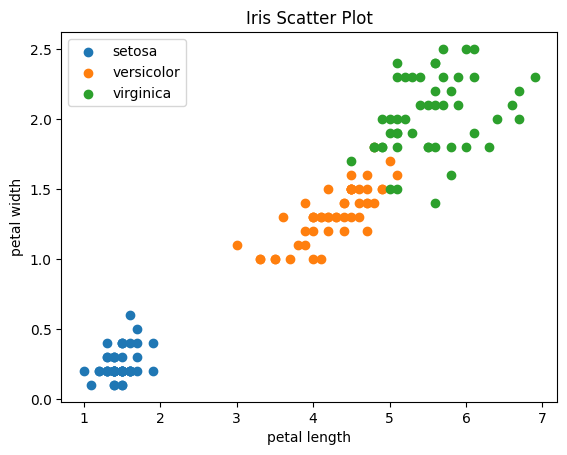

In [25]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris

iris = load_iris()
x = iris.data
y = iris.target

# 클래스별로 따로 그리기
for i, name in enumerate(iris.target_names):
    plt.scatter(
        x[y == i, 2],   # petal length
        x[y == i, 3],   # petal width
        label=name      # 🔥 핵심 (이름 붙이기)
    )

plt.xlabel("petal length")
plt.ylabel("petal width")
plt.title("Iris Scatter Plot")

plt.legend()   # 🔥 범례 표시
plt.show()

# 📊 결과 해석
# 🌸 setosa → 완전히 분리됨
# 🌼 versicolor / virginica → 겹침

# 👉 여기서 바로 강의 연결 가능:

# “선형 모델로는 완벽 분리가 어렵다 → 딥러닝 필요”

In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# -----------------------
# 1. 데이터
# -----------------------
iris = load_iris()
x = iris.data
y = iris.target

print(x)
print(y)

# -----------------------
# 2. train / validation 분리
# -----------------------
x_train, x_val, y_train, y_val = train_test_split(
    x, y, test_size=0.2, random_state=42
)

# -----------------------
# 3. 정규화
# -----------------------
#👉 정규화 = 입력 스케일을 맞춰서 학습을 빠르고 안정적으로 만든다
# 꽃잎 길이: 1 ~ 7
# 꽃잎 너비: 0.1 ~ 2
# 🔥 3. 효과 (진짜 중요)
# ✅ 1. 학습 속도 ↑
# gradient 안정
# ✅ 2. 수렴 안정성 ↑
# 발산 방지
# ✅ 3. 모든 feature 공정하게 사용
# 주의 train 데이터 기준으로만 기준 잡아야 함

# 🧠 5. 직관적인 비유
# 키(cm) + 몸무게(kg) 같이 쓰는데

# 한쪽만 단위가 크면
# 모델이 그쪽만 본다

# 👉 정규화 = “단위 맞추기”
scaler = StandardScaler() # 표준정규화
x_train = scaler.fit_transform(x_train)
x_val = scaler.transform(x_val)

# | 상황               | 필요       |
# | ---------------- | -------- |
# | 신경망 (Dense, CNN) | 거의 필수    |
# | 거리 기반 모델 (KNN)   | 필수       |
# | 트리 모델            | 거의 필요 없음 |


# -----------------------
# 4. 모델
# -----------------------
model = tf.keras.Sequential([
    tf.keras.layers.Dense(32, activation='relu', input_shape=(4,)),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(3, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# -----------------------
# 5. 학습 (history 저장🔥)
# -----------------------
history = model.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    epochs=100,
    verbose=0
)

[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]
 [5.4 3.9 1.7 0.4]
 [4.6 3.4 1.4 0.3]
 [5.  3.4 1.5 0.2]
 [4.4 2.9 1.4 0.2]
 [4.9 3.1 1.5 0.1]
 [5.4 3.7 1.5 0.2]
 [4.8 3.4 1.6 0.2]
 [4.8 3.  1.4 0.1]
 [4.3 3.  1.1 0.1]
 [5.8 4.  1.2 0.2]
 [5.7 4.4 1.5 0.4]
 [5.4 3.9 1.3 0.4]
 [5.1 3.5 1.4 0.3]
 [5.7 3.8 1.7 0.3]
 [5.1 3.8 1.5 0.3]
 [5.4 3.4 1.7 0.2]
 [5.1 3.7 1.5 0.4]
 [4.6 3.6 1.  0.2]
 [5.1 3.3 1.7 0.5]
 [4.8 3.4 1.9 0.2]
 [5.  3.  1.6 0.2]
 [5.  3.4 1.6 0.4]
 [5.2 3.5 1.5 0.2]
 [5.2 3.4 1.4 0.2]
 [4.7 3.2 1.6 0.2]
 [4.8 3.1 1.6 0.2]
 [5.4 3.4 1.5 0.4]
 [5.2 4.1 1.5 0.1]
 [5.5 4.2 1.4 0.2]
 [4.9 3.1 1.5 0.2]
 [5.  3.2 1.2 0.2]
 [5.5 3.5 1.3 0.2]
 [4.9 3.6 1.4 0.1]
 [4.4 3.  1.3 0.2]
 [5.1 3.4 1.5 0.2]
 [5.  3.5 1.3 0.3]
 [4.5 2.3 1.3 0.3]
 [4.4 3.2 1.3 0.2]
 [5.  3.5 1.6 0.6]
 [5.1 3.8 1.9 0.4]
 [4.8 3.  1.4 0.3]
 [5.1 3.8 1.6 0.2]
 [4.6 3.2 1.4 0.2]
 [5.3 3.7 1.5 0.2]
 [5.  3.3 1.4 0.2]
 [7.  3.2 4.7 1.4]
 [6.4 3.2 4.5 1.5]
 [6.9 3.1 4.

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


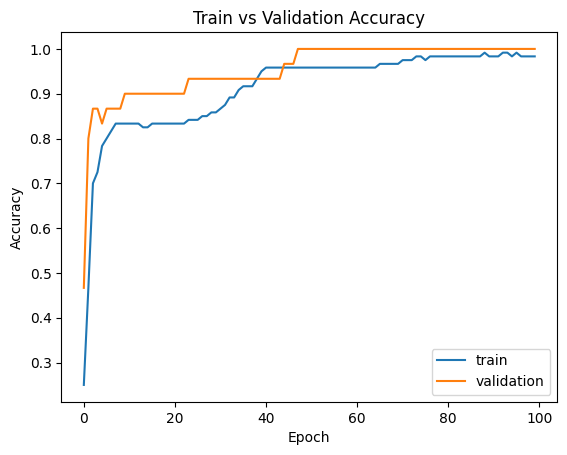

In [ ]:
plt.figure()

# train vs validation 같이
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='validation')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Train vs Validation Accuracy')

plt.legend()
plt.show()

# 🚀 5. 한 줄 핵심

# 👉 validation이 꺾이는 지점 = 과적합 시작

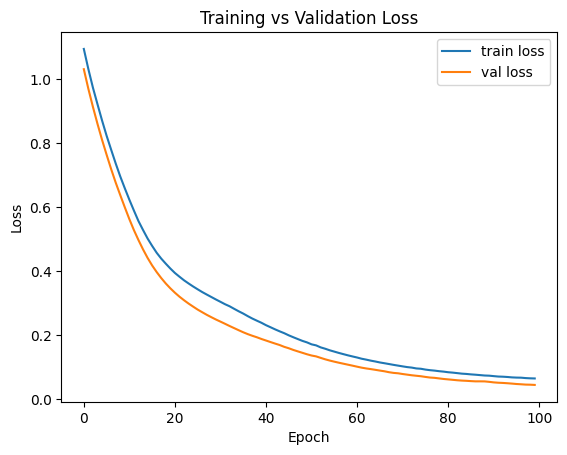

In [33]:
plt.figure()
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.show()

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.


/usr/share/fonts/truetype/nanum/NanumGothicBold.ttf
/usr/share/fonts/truetype/liberation/LiberationSans-Regular.ttf
/usr/share/fonts/truetype/nanum/NanumMyeongjoBold.ttf
/usr/share/fonts/truetype/liberation/LiberationSansNarrow-BoldItalic.ttf
/usr/share/fonts/truetype/nanum/NanumBarunGothicBold.ttf
/usr/share/fonts/truetype/nanum/NanumSquareB.ttf
/usr/share/fonts/truetype/liberation/LiberationSerif-Bold.ttf
/usr/share/fonts/truetype/liberation/LiberationSerif-Regular.ttf
/usr/share/fonts/truetype/liberation/LiberationSerif-Italic.ttf
/usr/share/fonts/truetype/nanum/NanumGothicCoding.ttf
/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf
/usr/share/fonts/truetype/liberation/LiberationMono-Regular.ttf
/usr/share/fonts/truetype/nanum/NanumSquareRoundB.ttf
/usr/share/fonts/truetype/liberation/LiberationSansNarrow-Italic.ttf
/usr/share/fonts/truetype/liberation/LiberationMono-Italic.ttf
/usr/share/fonts/truetype/liberation/LiberationSansNarrow-Bold.ttf
/usr/share/fonts/truetype/nanum/Nanu

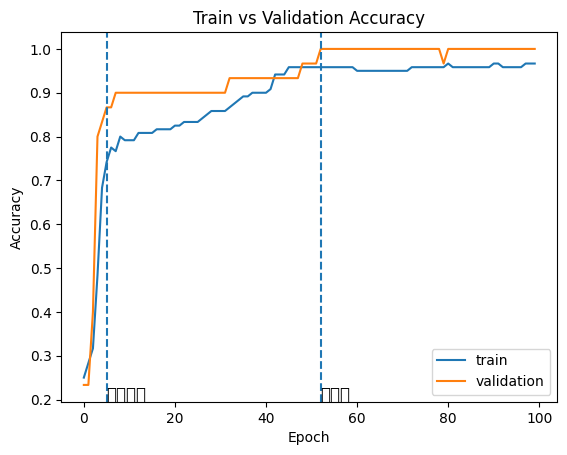

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

import matplotlib.font_manager as fm
!apt-get install -y fonts-nanum

for font in fm.findSystemFonts():
    print(font)

plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

# -----------------------
# 과적합 시작 지점
# -----------------------
overfit_epoch = np.argmax(val_acc)

# -----------------------
# 과소적합 구간 (초반)
# -----------------------
underfit_epoch = 5

plt.figure()

# 그래프
plt.plot(acc, label='train')
plt.plot(val_acc, label='validation')

# -----------------------
# 세로선 (기준선)
# -----------------------
plt.axvline(x=underfit_epoch, linestyle='--')
plt.axvline(x=overfit_epoch, linestyle='--')

# -----------------------
# 🔥 한글 가로 라벨 (핵심)
# -----------------------
plt.text(underfit_epoch, 0.2, '과소적합', fontsize=12)
plt.text(overfit_epoch, 0.2, '과적합', fontsize=12)

# -----------------------
# 기타 설정
# -----------------------
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Train vs Validation Accuracy')

plt.legend()
plt.show()

# 🚀 5. 한 줄 핵심

# 👉 validation이 꺾이는 지점 = 과적합 시작